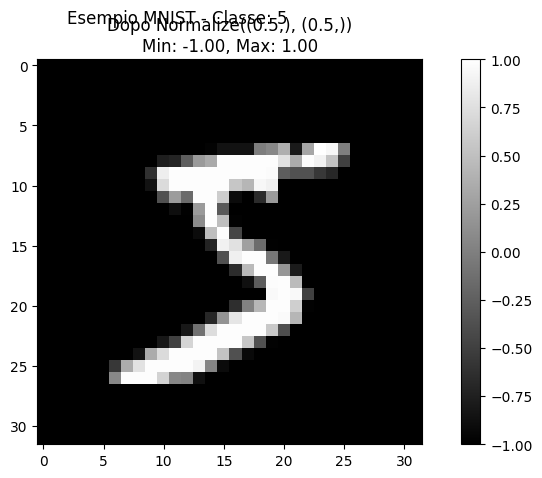

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import random_split

# Trasformazioni: LeNet-5 originale prevede input 32x32,
# MNIST è 28x28, quindi aggiungiamo del padding.
transform = transforms.Compose([
    transforms.Pad(2),
    transforms.ToTensor(), # Porta le immagini da 255 valori per pixel a [0,1]
    transforms.Normalize((0.5,), (0.5,)) #Sottrae dai pixel 0.5 e divide per 0,5 per portare o valori all'intervallo [-1,1]
])

full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_size = 50000
val_size = 10000
train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])

# Creiamo i DataLoader
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

def visualizza(idx):
    img_norm, label = full_train_dataset[idx]

    fig, (ax2) = plt.subplots(1, 1, figsize=(10, 5))


    # Immagine Normalizzata (-1, 1)
    im2 = ax2.imshow(img_norm.squeeze(), cmap='gray')
    ax2.set_title(f"Dopo Normalize((0.5,), (0.5,))\nMin: {img_norm.min():.2f}, Max: {img_norm.max():.2f}")
    plt.colorbar(im2, ax=ax2)

    plt.suptitle(f"Esempio MNIST - Classe: {label}")
    plt.show()

visualizza(0)


In [7]:
def check_accuracy(loader, model):
    num_correct = 0
    num_samples = 0
    model.eval() # Imposta il modello in modalità valutazione

    with torch.no_grad(): # Disabilita il calcolo dei gradienti per risparmiare memoria
        for x, y in loader:
            scores = model(x)
            _, predictions = scores.max(1) # Otteniamo l'indice della classe con probabilità maggiore
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

    model.train() # Torna in modalità training
    return (float(num_correct) / num_samples) * 100

In [5]:
#Definisco Lenet 5
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # Layer Convoluzionale 1: 6 filtri 5x5
        self.c1 = nn.Conv2d(1, 6, kernel_size=5) #1 canale, 6 filtri di grandezza 5x5. Passo da 32x32 a 28x28
        # Layer Max Pooling 1: riduce la dimensione spaziale
        self.s2 = nn.MaxPool2d(kernel_size=2, stride=2) #passo da 28x28x6 a 14x14x6
        # Layer Convoluzionale 2: 16 filtri 5x5
        self.c3 = nn.Conv2d(6, 16, kernel_size=5) #da 6 canali a 16 filtri di grandezza 5x5. Passo 14x14x6 a 10x10x16
        # Layer Max Pooling 2
        self.s4 = nn.MaxPool2d(kernel_size=2, stride=2) #passo da 10x10x16 a 5x5x16

        # Layer completamente connessi (MLP) per la classificazione finale
        self.fc1 = nn.Linear(16 * 5 * 5, 120) #Layer con 120 neuroni
        self.fc2 = nn.Linear(120, 84) #layer con 84 neuroni
        self.fc3 = nn.Linear(84, 10) # 10 classi (cifre 0-9)

        # Funzione di attivazione: ReLU è la più utilizzata nella pratica
        self.relu = nn.ReLU()

    def forward(self, x):
        # Forward pass: PyTorch costruisce il grafo computazionale qui
        x = self.relu(self.c1(x))
        x = self.s2(x)
        x = self.relu(self.c3(x))
        x = self.s4(x)

        # Flattening per passare ai layer densi
        x = x.view(-1, 16 * 5 * 5)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = LeNet5()

In [9]:
# Loop di Training
# Definizione Loss e Ottimizzatore
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # Gradient Descent

for epoch in range(5):
    for batch_idx, (data, targets) in enumerate(train_loader):
        # Forward pass: calcolo delle attivazioni e della loss
        scores = model(data)
        loss = loss_function(scores, targets)

        # Backward pass: automatic differentiation tramite backpropagation
        optimizer.zero_grad()
        loss.backward() #Calcola i gradienti

        # Aggiornamento dei pesi w e b-> Gradient Descent
        optimizer.step()

    # Controllo accuracy alla fine di ogni epoca
    train_acc = check_accuracy(train_loader, model)
    val_acc = check_accuracy(val_loader, model)

    print(f"Epoch {epoch+1} conclusa. Loss: {loss.item():.4f}")
    print(f"Accuracy - Training: {train_acc:.2f}%, Validation: {val_acc:.2f}%")

Epoch 1 conclusa. Loss: 0.0861
Accuracy - Training: 98.25%, Validation: 97.67%
Epoch 2 conclusa. Loss: 0.0029
Accuracy - Training: 98.72%, Validation: 98.23%
Epoch 3 conclusa. Loss: 0.0002
Accuracy - Training: 99.28%, Validation: 98.66%


KeyboardInterrupt: 

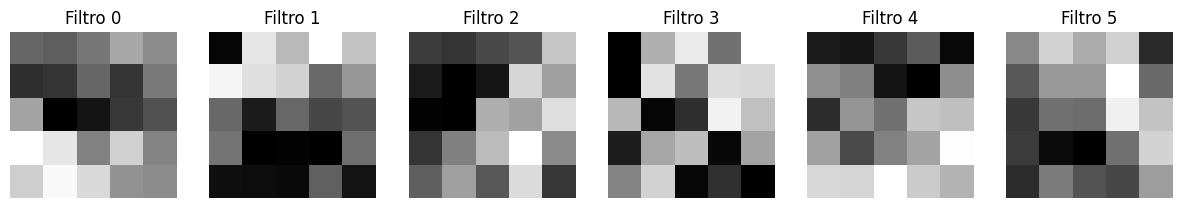

In [10]:
import matplotlib.pyplot as plt

def visualizza_filtri(model):
    # Estraiamo i pesi del primo layer convoluzionale
    filters = model.c1.weight.data.cpu().numpy()

    # Creiamo una griglia per i 6 filtri di LeNet-5
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))

    for i, ax in enumerate(axes):
        # Ogni filtro è 5x5
        filtro = filters[i][0]
        ax.imshow(filtro, cmap='gray')
        ax.set_title(f"Filtro {i}")
        ax.axis('off')

    plt.show()

visualizza_filtri(model)

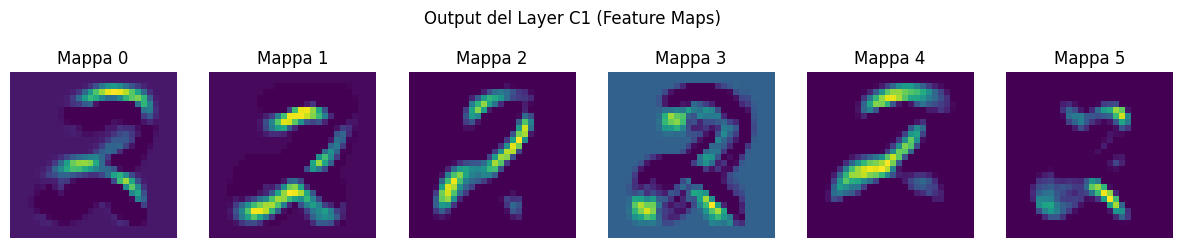

In [13]:
def visualizza_attivazioni(model, immagine):
    model.eval()
    with torch.no_grad():
        # Passiamo l'immagine nel primo layer
        attivazione_c1 = model.relu(model.c1(immagine.unsqueeze(0)))

    # Visualizziamo i 6 canali in uscita dal primo layer
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i in range(6):
        axes[i].imshow(attivazione_c1[0, i].cpu(), cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f"Mappa {i}")

    plt.suptitle("Output del Layer C1 (Feature Maps)")
    plt.show()

# Prendi un'immagine dal test_loader e visualizzala
dataiter = iter(val_loader)
immagini, labels = next(dataiter)
visualizza_attivazioni(model, immagini[1])

Filtro di contrasto: Alcune mappe evidenzieranno solo i bordi verticali del numero, altre quelli orizzontali.

Riduzione del rumore: La rete impara a ignorare i pixel neri di sfondo e a concentrarsi solo sulla forma del numero.


Gerarchia: Se ripetessi l'operazione per il layer c3, vedremmo mappe molto più astratte e rimpicciolite (a causa del pooling), dove ogni "punto" luminoso indica la presenza di una caratteristica complessa .

## ora consideriamo la seconda rete: AlexNet

In [ ]:
transform_alexnet = transforms.Compose([
    transforms.Resize(224),           # Ridimensiona da 28x28 a 224x224
    transforms.Grayscale(num_output_channels=3), # Converte 1 canale in 3 (R=G=B)
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Carica il dataset con il nuovo transform
full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_alexnet)
train_size = 50000
val_size = 10000
train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])

# Creiamo i DataLoader
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

In [ ]:
class AlexNetMNIST(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNetMNIST, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = AlexNetMNIST()

In [ ]:
# 1. Configurazione del Device
# Controlla se è disponibile una GPU NVIDIA (cuda) o il chip Apple Silicon (mps)
#ATTENAZIONE PER LE PROSSIME CELLE È NECESSARIA LA GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.devce("cpu")

print(f"Sto usando il device: {device}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim



# 2. Inizializzazione Modello, Loss e Ottimizzatore
# IMPORTANTE: Sposta subito il modello sul device
model = AlexNetMNIST().to(device) # o LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Funzione per il controllo dell'accuracy (su Device)
def check_accuracy(loader, model, device):
    num_correct = 0
    num_samples = 0
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            # Sposta i dati del validation set sul device
            x = x.to(device)
            y = y.to(device)

            scores = model(x)
            _, predictions = scores.max(1)
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

    model.train()
    return (float(num_correct) / num_samples) * 100

# 4. Ciclo di Training Completo
num_epochs = 5

for epoch in range(num_epochs):
    running_loss = 0.0
    model.train()

    for batch_idx, (data, targets) in enumerate(train_loader):
        # Sposta immagini e labels sul device
        data = data.to(device)
        targets = targets.to(device)

        # Forward pass
        scores = model(data)
        loss = criterion(scores, targets)

        # Backward pass (Backpropagation)
        optimizer.zero_grad() # Fondamentale per non accumulare i gradienti
        loss.backward()

        # Aggiornamento dei pesi
        optimizer.step()

        running_loss += loss.item()

    # Calcolo accuracy a fine epoca
    train_acc = check_accuracy(train_loader, model, device)
    val_acc = check_accuracy(val_loader, model, device)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {running_loss/len(train_loader):.4f}")
    print(f"Accuracy -> Training: {train_acc:.2f}%, Validation: {val_acc:.2f}%")
    print("-" * 30)

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualizza_attivazioni_alexnet(model, dataset, device, img_idx=0):
    model.eval()

    # 1. Prendi un'immagine di test e spostala sul device
    img, label = dataset[img_idx]
    img_input = img.unsqueeze(0).to(device)
    # 1. Preparazione immagine per la visualizzazione
    # Da [3, 224, 224] a [224, 224, 3]
    img_vis = img.permute(1, 2, 0).numpy()
    # Denormalizzazione (riporta da [-1, 1] a [0, 1])
    img_vis = img_vis * 0.5 + 0.5
    img_vis = np.clip(img_vis, 0, 1)
    with torch.no_grad():
        # Estraiamo l'output del primo strato (Conv2d + ReLU)
        # Nella nostra AlexNet, features[0] è la Conv e features[1] è la ReLU
        first_layer_conv = model.features[0](img_input)
        first_layer_activation = torch.relu(first_layer_conv)

        # Estraiamo l'output del secondo blocco convoluzionale (opzionale)
        # features[3] è la seconda Conv2d
        second_layer_activation = torch.relu(model.features[3](model.features[2](first_layer_activation)))

    # 2. Visualizzazione del PRIMO LAYER (64 filtri totali, ne mostriamo 12)
    fig, axes = plt.subplots(2, 7, figsize=(20, 6))

    # Immagine Originale
    axes[0, 0].imshow(img_vis.squeeze(), cmap='gray')
    axes[0, 0].set_title(f"Originale\n(Label: {label})")
    axes[0, 0].axis('off')

    # Mostriamo i primi 12 filtri del Layer 1
    for i in range(13):
        if i == 0: continue # Salta il posto dell'originale
        idx = i - 1
        row = i // 7
        col = i % 7
        axes[row, col].imshow(first_layer_activation[0, idx].cpu(), cmap='Grays')
        axes[row, col].set_title(f"Filtro {idx}")
        axes[row, col].axis('off')

    plt.suptitle("AlexNet - Attivazioni del Primo Layer (Rilevamento Bordi)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Esecuzione (assicurati che 'val_subset' sia il dataset corretto)
visualizza_attivazioni_alexnet(model, val_subset, device, img_idx=16)

# Passiamo ora alla resnet e al transfer learning

### Carichiamo il dataset

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
import os

# 1. Definiamo le trasformazioni
# Le ResNet vogliono input 224x224.
# I valori di mean e std sono standard per i modelli pre-addestrati su ImageNet.
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224), # Data Augmentation (solo training)
        transforms.RandomHorizontalFlip(), # Data Augmentation (solo training)
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 2. Percorso dei dati
data_dir = 'data/hymenoptera_data/hymenoptera_data'

# 3. Creiamo i Dataset usando ImageFolder
# ImageFolder capisce da solo che la cartella "ants" è la classe 0 e "bees" la classe 1
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}

# 4. Creiamo i DataLoader
# Il DataLoader prende il dataset e crea i "batch" (pacchetti di immagini)
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=2)
              for x in ['train', 'val']}

# Utilità: Salviamo le dimensioni e i nomi delle classi
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Classi trovate: {class_names}")
print(f"Immagini di training: {dataset_sizes['train']}")
print(f"Immagini di validazione: {dataset_sizes['val']}")

Classi trovate: ['ants', 'bees']
Immagini di training: 244
Immagini di validazione: 153


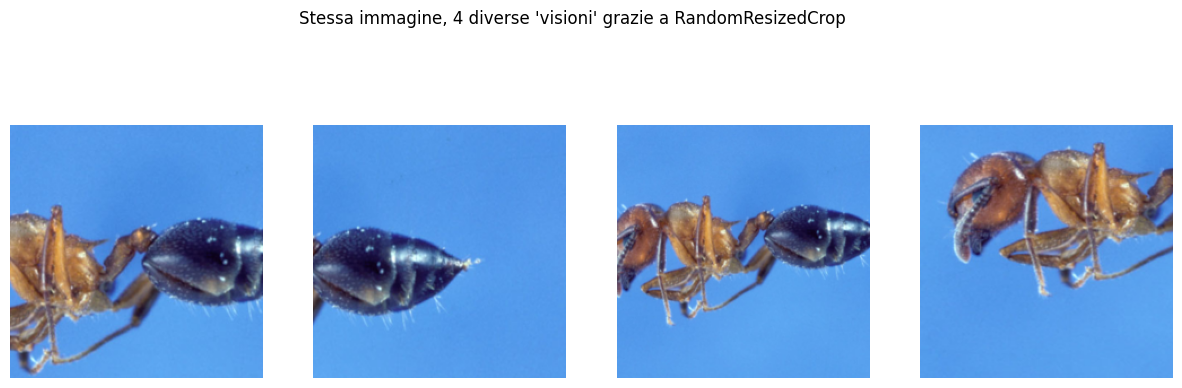

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

# 1. Carichiamo un'immagine singola (assicurati che il path sia giusto)
img_path = './data/hymenoptera_data/hymenoptera_data/train/ants/0013035.jpg' # Scegli un'immagine a caso
img = Image.open(img_path)

# 2. Definiamo SOLO la trasformazione RandomResizedCrop per far vedere cosa fa
# scale=(0.08, 1.0) significa: "Prendi un pezzo che va dall'8% al 100% dell'immagine originale"
augmenter = transforms.RandomResizedCrop(224, scale=(0.1, 1.0))

# 3. Visualizziamo 4 versioni "augmentate" della stessa immagine
fig, axs = plt.subplots(1, 4, figsize=(15, 5))
fig.suptitle("Stessa immagine, 4 diverse 'visioni' grazie a RandomResizedCrop")

for i in range(4):
    augmented_img = augmenter(img)
    axs[i].imshow(augmented_img)
    axs[i].axis('off')

plt.show()

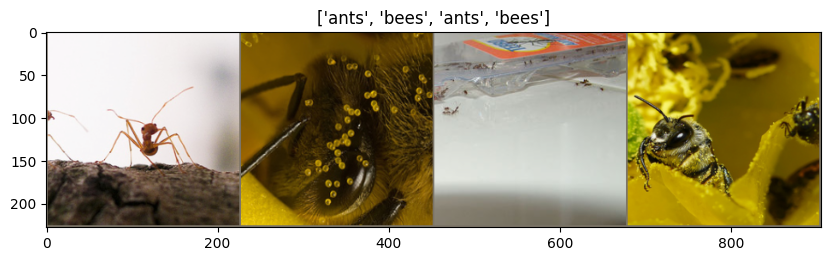

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def imshow(inp, title=None):
    """Funzione per mostrare un tensore come immagine"""
    inp = inp.numpy().transpose((1, 2, 0)) # Da (Canali, H, W) a (H, W, Canali)
    
    # Denormalizziamo (operazione inversa di quella fatta nel transform)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    
    # Clip per assicurarsi che i valori siano tra 0 e 1 per matplotlib
    inp = np.clip(inp, 0, 1)
    
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pausa per aggiornare i grafici

# Prendiamo un batch di dati di training per testare
inputs, classes = next(iter(dataloaders['train']))

# Creiamo una griglia
out = torchvision.utils.make_grid(inputs)

plt.figure(figsize=(10, 5))
imshow(out, title=[class_names[x] for x in classes])

In [28]:
# 1. Carichiamo il modello from scratch
#model = models.resnet50(weights=None)

# 1. Carichiamo il modello pre-trained
model = models.resnet50(weights='DEFAULT') # passo da 1000 classi a 2
model.fc = nn.Linear(model.fc.in_features, 2)

#2. Congeliamo TUTTI i parametri inizialmente per il fine tuning, altrimenti commentiamo
for param in model.parameters():
     param.requires_grad = False

# # 3. Sblocchiamo solo l'ultimo blocco fc)
for param in model.fc.parameters():
     param.requires_grad = True

# Spostiamo sul device
device = torch.device("cuda")

model = model.to(device)

# 4. L'ottimizzatore deve gestire solo i parametri "sbloccati" per il fine tiuning altrimenti tutti i parametri
#optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [29]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [30]:
import time
import copy

def train_model(model, criterion, optimizer, scheduler, num_epochs=3):
    since = time.time()

    # Per salvare i pesi del modello migliore (quello con la val_acc più alta)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Dizionari per salvare la storia e fare i grafici dopo
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoca {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Ogni epoca ha una fase di training e una di validazione
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Imposta il modello in modalità training (abilita Dropout, BatchNorm, ecc.)
            else:
                model.eval()   # Imposta il modello in modalità valutazione

            running_loss = 0.0
            running_corrects = 0

            # Iteriamo sui dati
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Azzeriamo i gradienti dei parametri
                optimizer.zero_grad()

                # Forward (passaggio in avanti)
                # Tracciamo la storia delle operazioni solo se siamo in training
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + Ottimizzazione solo se in training
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistiche
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            # Se siamo in training, facciamo avanzare lo scheduler (se presente)
            if phase == 'train' and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Salviamo i dati per i grafici
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            # Deep copy del modello se è il migliore finora
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training completato in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Miglior val Acc: {best_acc:.4f}')

    # Carichiamo i pesi migliori prima di restituire il modello
    model.load_state_dict(best_model_wts)
    return model, history

In [31]:
criterion = nn.CrossEntropyLoss()
# 3. Definiamo l'Optimizer
# SGD (Stochastic Gradient Descent) con momentum è un classico per le CNN
# Nota: ottimizziamo TUTTI i parametri qui, ma potresti ottimizzare solo model_ft.fc.parameters()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
# 4. (Opzionale) Learning Rate Scheduler
# Riduce il learning rate di un fattore 0.1 ogni 7 epoche
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# 5. AVVIO DEL TRAINING
model, history_ft = train_model(model, criterion, optimizer, exp_lr_scheduler, num_epochs=10)

Epoca 1/10
----------
train Loss: 0.6870 Acc: 0.5492
val Loss: 0.6600 Acc: 0.6275

Epoca 2/10
----------
train Loss: 0.6410 Acc: 0.7828
val Loss: 0.6045 Acc: 0.8627

Epoca 3/10
----------
train Loss: 0.6056 Acc: 0.7910
val Loss: 0.5596 Acc: 0.9150

Epoca 4/10
----------
train Loss: 0.5789 Acc: 0.8115
val Loss: 0.5197 Acc: 0.9412

Epoca 5/10
----------
train Loss: 0.5444 Acc: 0.8443
val Loss: 0.4741 Acc: 0.9412

Epoca 6/10
----------
train Loss: 0.5286 Acc: 0.8402
val Loss: 0.4704 Acc: 0.9608

Epoca 7/10
----------
train Loss: 0.5178 Acc: 0.8525
val Loss: 0.4367 Acc: 0.9477

Epoca 8/10
----------
train Loss: 0.4928 Acc: 0.8525
val Loss: 0.4418 Acc: 0.9542

Epoca 9/10
----------
train Loss: 0.4868 Acc: 0.8730
val Loss: 0.4367 Acc: 0.9608

Epoca 10/10
----------
train Loss: 0.5136 Acc: 0.8525
val Loss: 0.4397 Acc: 0.9608

Training completato in 1m 11s
Miglior val Acc: 0.9608


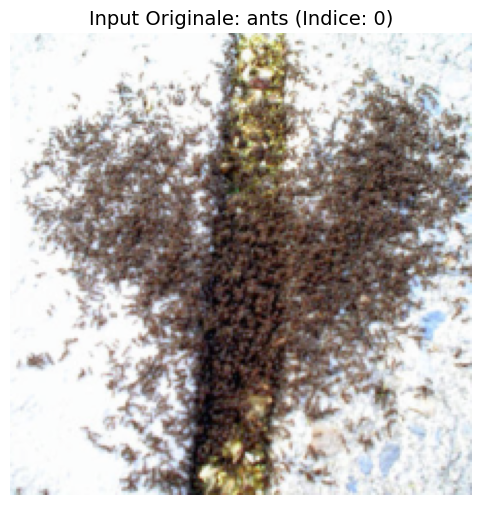

Generazione mappe di attivazione per ants...



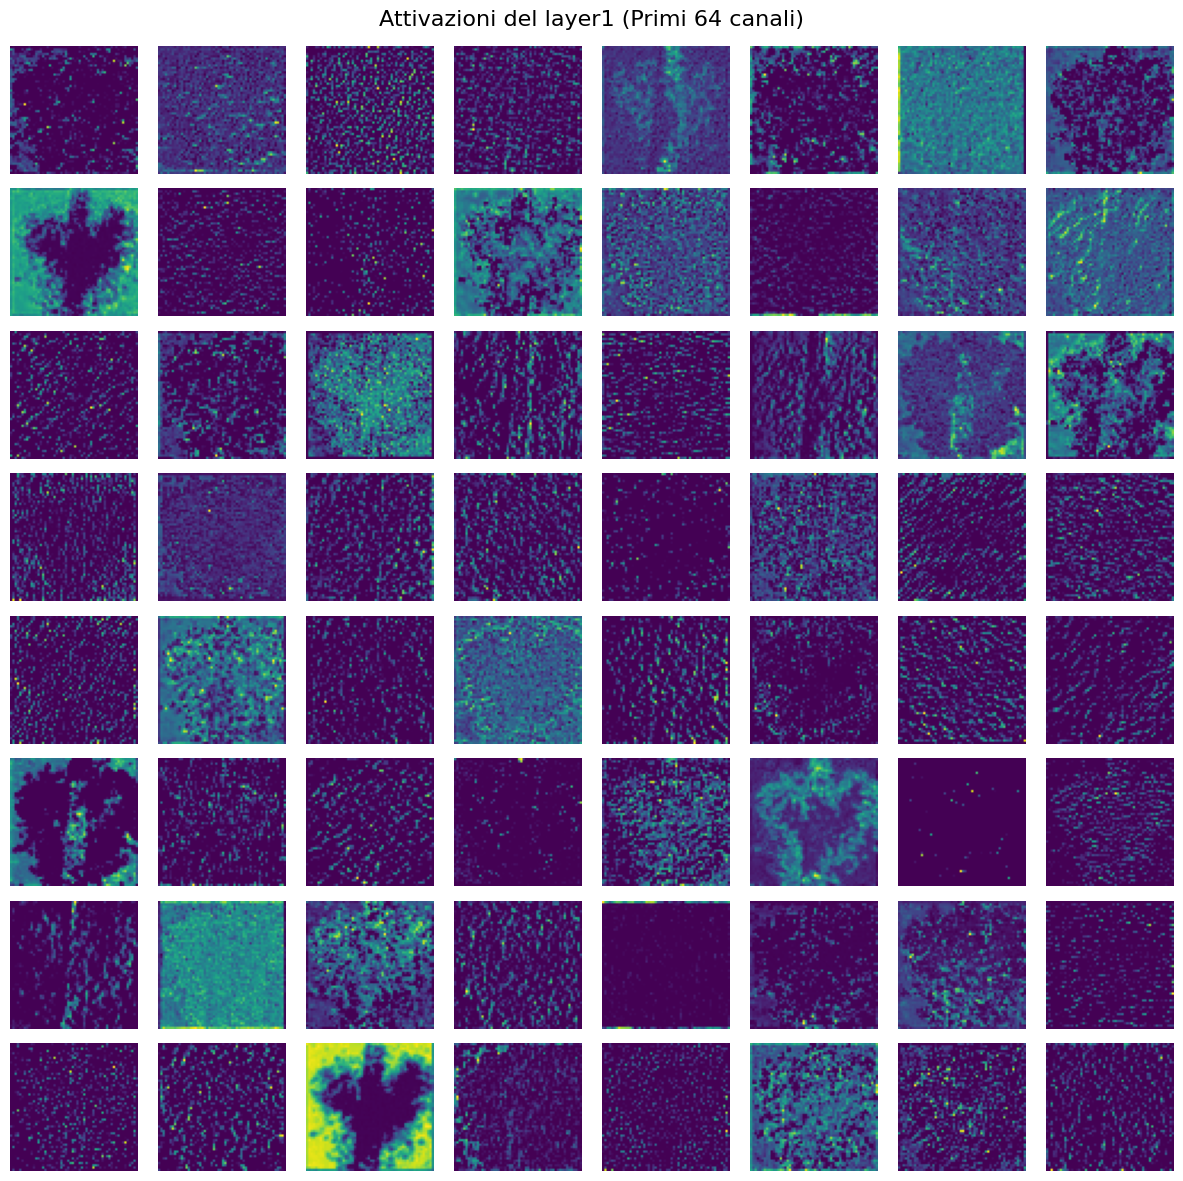

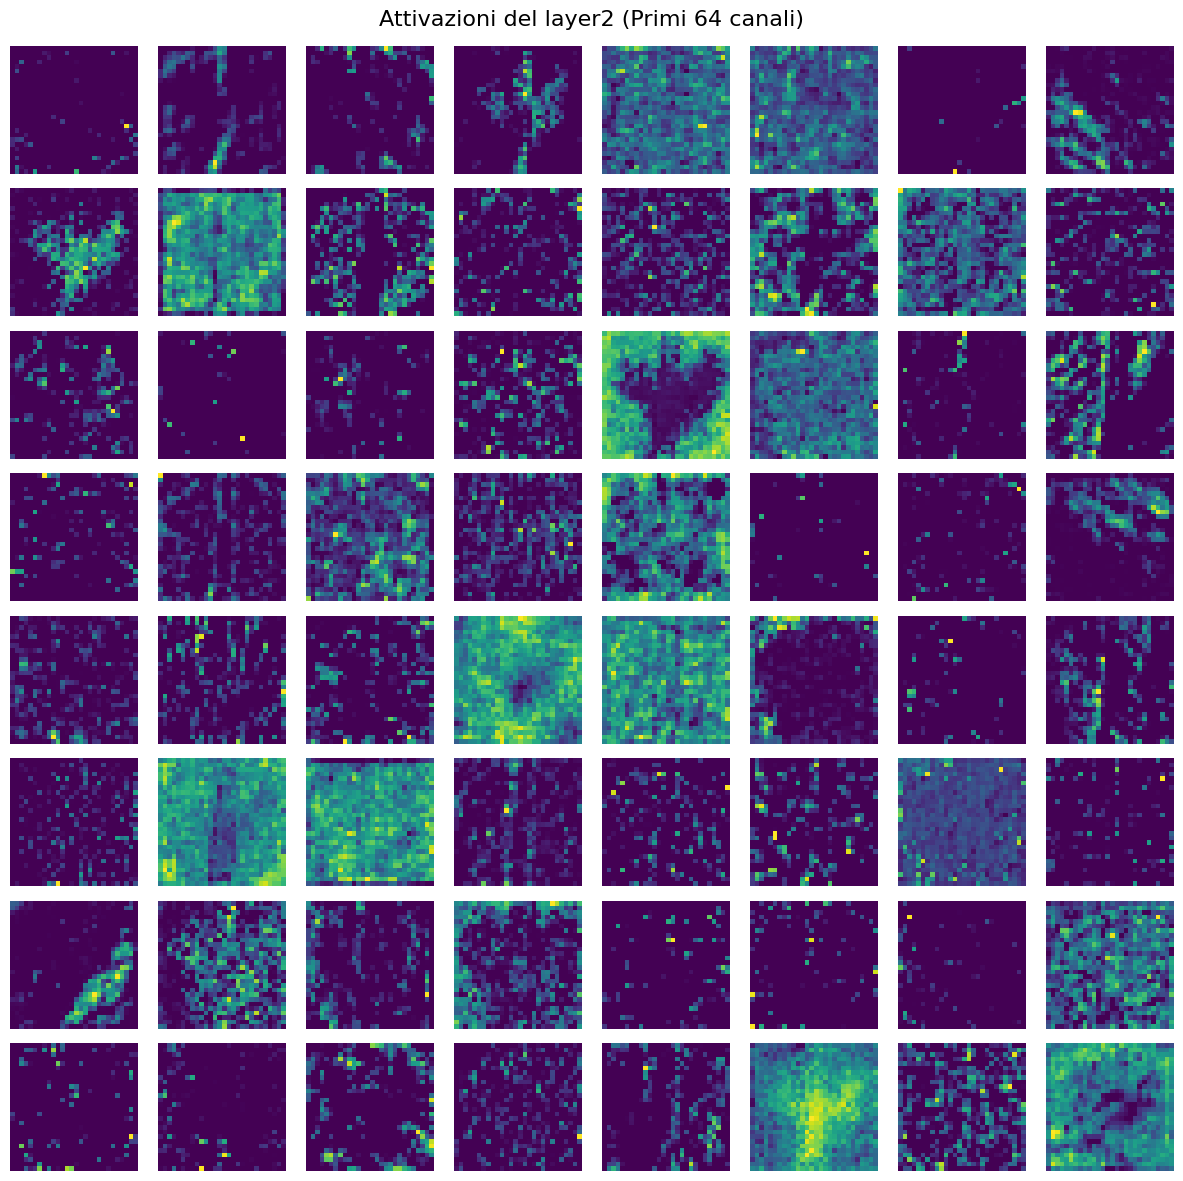

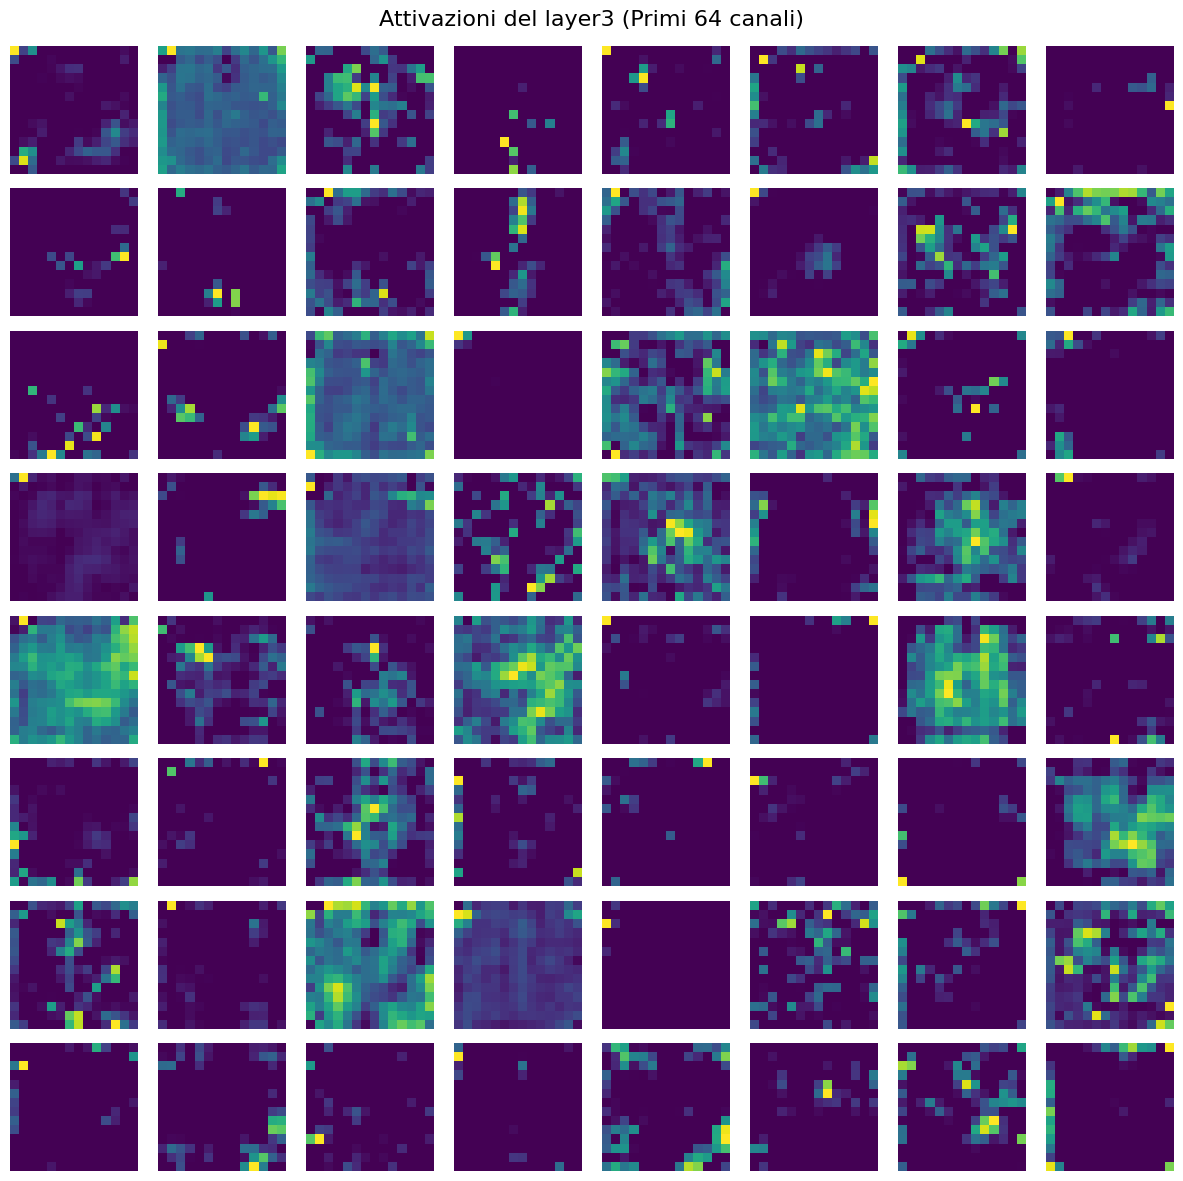

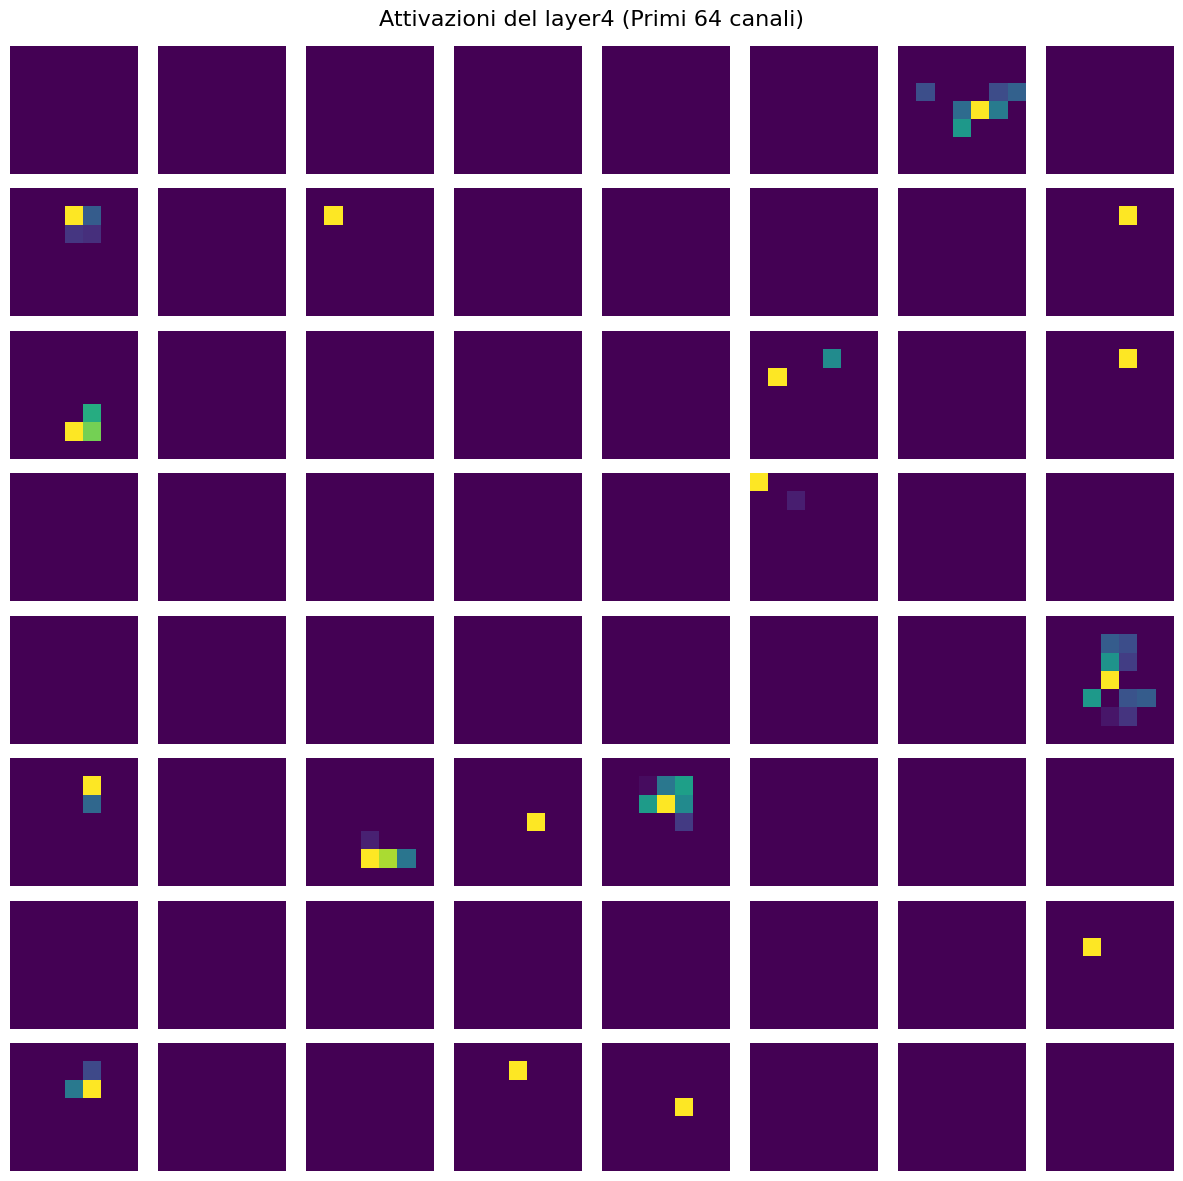

In [33]:
import matplotlib.pyplot as plt
import torch

# Dizionario per salvare le attivazioni
activations = {}

def get_activation(name):
    """Funzione 'Hook' che intercetta l'output di un layer e lo salva"""
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

def visualize_layer_activations(model, img_tensor):
    # 1. Registriamo gli hooks sui layer che ci interessano (ResNet specifici)
    # Layer 1: Caratteristiche di basso livello (linee, texture fini)
    # Layer 4: Caratteristiche di alto livello (forme complesse, parti di oggetti)
    hooks = []
    layers_to_hook = ['layer1', 'layer2', 'layer3', 'layer4']
    
    for name in layers_to_hook:
        layer = getattr(model, name)
        # Registriamo l'hook e salviamo l'handle per rimuoverlo dopo
        hooks.append(layer.register_forward_hook(get_activation(name)))
    
    # 2. Facciamo passare l'immagine (Forward pass)
    model.eval()
    with torch.no_grad():
        # Aggiungiamo la dimensione del batch se manca (C, H, W) -> (1, C, H, W)
        if img_tensor.dim() == 3:
            img_tensor = img_tensor.unsqueeze(0)
        _ = model(img_tensor.to(device))
    
    # 3. Rimuoviamo gli hooks (pulizia)
    for h in hooks:
        h.remove()
        
    # 4. Visualizziamo le attivazioni
    for layer_name in layers_to_hook:
        act = activations[layer_name].squeeze() # Rimuove dim batch -> (Canali, H, W)
        
        # Prendiamo solo i primi 64 canali/filtri per non intasare il grafico
        num_channels = min(act.shape[0], 64) 
        
        fig, axes = plt.subplots(8, 8, figsize=(12, 12))
        fig.suptitle(f"Attivazioni del {layer_name} (Primi 64 canali)", fontsize=16)
        
        for i in range(8 * 8):
            row = i // 8
            col = i % 8
            ax = axes[row, col]
            
            if i < num_channels:
                # Mostriamo la mappa di attivazione i-esima
                ax.imshow(act[i].cpu(), cmap='viridis')
            
            ax.axis('off')
            
        plt.tight_layout()
        plt.subplots_adjust(top=0.95)
        plt.show()

import numpy as np

def show_original_and_activations(model, dataset, img_index=0):
    """
    Mostra l'immagine originale denormalizzata e poi le attivazioni dei layer
    """
    # 1. Recuperiamo l'immagine e l'etichetta dal dataset
    img_tensor, label_idx = dataset[img_index]
    class_name = dataset.classes[label_idx]
    
    # 2. Denormalizzazione per la visualizzazione umana
    # (Invertiamo la trasformazione fatta nel dataloader)
    inp = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) # Assicuriamoci che i valori siano tra 0 e 1

    # 3. Mostriamo l'Immagine Originale
    plt.figure(figsize=(6, 6))
    plt.imshow(inp)
    plt.title(f"Input Originale: {class_name} (Indice: {img_index})", fontsize=14)
    plt.axis('off')
    plt.show()

    print(f"Generazione mappe di attivazione per {class_name}...\n")
    
    # 4. Chiamiamo la funzione di visualizzazione attivazioni (definita prima)
    # Nota: Assicurati che 'visualize_layer_activations' sia già definita nel notebook
    visualize_layer_activations(model, img_tensor)

# --- ESECUZIONE ---
show_original_and_activations(model, image_datasets['val'], img_index=0)